In [13]:
## Step 1 - Imports ##

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

In [14]:
## Step 2 - Load the data ##

# Load well datasets
well1 = pd.read_csv("1_2021002_.csv")
well4 = pd.read_csv("4_20211022_.csv")
well7 = pd.read_csv("7_2021022_.csv")

In [15]:
## Step 3 - Fix column issues ##

# Fix inconsistent column names
well4 = well4.rename(columns={"litholody": "lithology"})
well7 = well7.rename(columns={"litholody": "lithology"})

# Add well labels
well1["well"] = "well1"
well4["well"] = "well4"
well7["well"] = "well7"

# Combine data
all_data = pd.concat([well1, well4, well7], axis=0)

In [16]:
## Step 4 - Clean the data ##

# Fix depth naming
all_data = all_data.rename(columns={"depth(m)": "depth"})

# Remove duplicate columns
all_data = all_data.loc[:, ~all_data.columns.duplicated()]

# Keep only relevant columns (NO depth to avoid problems)
columns = ["SP", "GR", "LLD", "LLS", "DEN", "AC", "lithology", "well"]
all_data = all_data[columns]

# Drop rows where lithology is missing
all_data = all_data.dropna(subset=["lithology"])

# Define features - no depth
features = ["SP", "GR", "LLD", "LLS", "DEN", "AC"]

In [17]:
## Step 5 - Split by well ##

train_data = all_data[all_data["well"] != "well7"]
test_data = all_data[all_data["well"] == "well7"]

In [20]:
## Step 6 - Build X and y ##

X_train = train_data[features]
X_test = test_data[features]

le = LabelEncoder()

y_train = le.fit_transform(train_data["lithology"])
y_test = le.transform(test_data["lithology"])

In [21]:
## Step 7 - Handle missing values ##

X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())

In [22]:
## Step 8 - Train Decision Tree ##

tree_model = DecisionTreeClassifier(max_depth=4)

tree_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4)

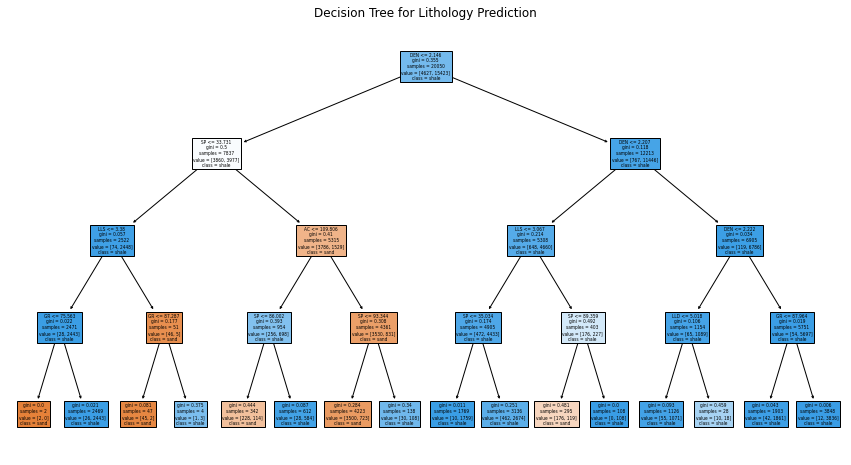

In [24]:
## Step 9 - Plot the Decision Tree ##

plt.figure(figsize=(15,8))

plot_tree(
    tree_model,
    feature_names=features,
    class_names=le.classes_,
    filled=True
)

plt.title("Decision Tree for Lithology Prediction")
plt.show()

In [26]:
## Step 10 - Predict and accuracy ##

y_pred = tree_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9021971315227342


In [ ]:
## Step 11 - Interpret the model ##

The decision tree model was developed to classify lithology (sand versus shale) using well log measurements from multiple wells. The data from three wells were first combined and cleaned by correcting column inconsistencies, removing missing lithology values, and selecting relevant features such as SP, GR, LLD, LLS, DEN, and AC. A well-based train–test strategy was used, where the model was trained on two wells and evaluated on a completely unseen third well to ensure realistic performance. After preprocessing, a decision tree classifier with limited depth was trained to improve interpretability. The model achieved approximately 90% accuracy, demonstrating that decision trees can effectively capture relationships between log responses and lithology. The resulting tree structure provided clear, interpretable rules for classification, with features such as gamma ray and density playing a dominant role in separating rock types. Overall, the decision tree offered strong predictive performance while allowing straightforward geological interpretation through explicit decision rules.